# Notebook 4 — Bubble Diagnostics

This notebook computes the bubble existence conditions from **Theorem 1** and **Corollary 1** of `Corollary_V3.tex`:

1. **Leakage ratio** $a_t$ (proof of Theorem 1, lines 688–698)
2. **Corollary 1 primitive conditions**:
   - (2a): $\sum D_t^u / e_{US,t}^u < \infty$
   - (2b): $\sum (C_t^b / C_t^u)^{1-\gamma} < \infty$
3. **Fundamental value** decomposition: $Q_{US,t} = V_t + B_t$
4. Four-panel diagnostic plots

In [19]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Documents/GitHub/Open_HKT`


Plots.GRBackend()

In [20]:
# ── Run the full simulation ──
result = run_simulation(ModelParams(); verbose=true);

Generating exogenous paths...
Solving balanced-growth states...
  t= 20: ω_b=0.3772  θ_b=-1.640976  R_f_b=1.0760
  t= 40: ω_b=0.5907  θ_b=-1.001587  R_f_b=1.0626
  t= 60: ω_b=0.7334  θ_b=-0.735930  R_f_b=1.0551
  t= 80: ω_b=0.7846  θ_b=-0.647760  R_f_b=1.0526
  t=100: ω_b=0.7970  θ_b=-0.624885  R_f_b=1.0516
  t=120: ω_b=0.7994  θ_b=-0.619589  R_f_b=1.0513
Solving u-path by backward induction...


┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Documents/GitHub/Open_HKT/TwoCountryOLG.jl:595


  t=110: ω=0.8492  θ=-0.621327  θ*_US=+620.9957  R_f=1.1317  q_US=0.425164  ‖F‖=3.3e-15
  t=100: ω=0.8126  θ=-0.624891  θ*_US=+298.8460  R_f=1.1319  q_US=0.407326  ‖F‖=2.0e-14
  t= 90: ω=0.7759  θ=-0.632217  θ*_US=+144.6722  R_f=1.1321  q_US=0.389197  ‖F‖=1.7e-14
  t= 80: ω=0.7376  θ=-0.646998  θ*_US=+70.8430  R_f=1.1323  q_US=0.369578  ‖F‖=2.7e-15
  t= 70: ω=0.7005  θ=-0.676091  θ*_US=+35.4222  R_f=1.1325  q_US=0.349122  ‖F‖=1.7e-15
  t= 60: ω=0.6653  θ=-0.731347  θ*_US=+18.3345  R_f=1.1325  q_US=0.328981  ‖F‖=1.1e-15
  t= 50: ω=0.6258  θ=-0.830638  θ*_US=+9.9640  R_f=1.1321  q_US=0.311326  ‖F‖=3.2e-15
  t= 40: ω=0.5684  θ=-0.996442  θ*_US=+5.7194  R_f=1.1309  q_US=0.300513  ‖F‖=6.0e-16
  t= 30: ω=0.4843  θ=-1.254894  θ*_US=+3.4465  R_f=1.1279  q_US=0.304515  ‖F‖=1.1e-16
  t= 20: ω=0.3875  θ=-1.639636  θ*_US=+2.1547  R_f=1.1210  q_US=0.336425  ‖F‖=4.3e-15
  t= 10: ω=0.3117  θ=-2.191486  θ*_US=+1.3780  R_f=1.1064  q_US=0.416945  ‖F‖=2.9e-13
  u-path: 119/119 periods converged.
Computin

In [21]:
p    = result.params
diag = result.diagnostics
u_path = result.u_path
paths  = result.paths
bs     = result.balanced_states
T = p.T_max
tt = 1:T

# Pre-compute Q vectors for later use
Q_US_vec = [u_path[t].Q_US for t in tt]
Q_W_vec  = [u_path[t].Q_W  for t in tt];

## 1. Corollary 1 — Primitive Conditions

### Condition (2a): $\sum_{t=1}^\infty D_t^u / e_{US,t}^u < \infty$

This is a geometric series with ratio $g_{D,u}/g_{e,u}$. It converges whenever $g_{D,u} < g_{e,u}$ (dividends grow slower than endowments in state $u$).

### Condition (2b): $\sum_{t=1}^\infty (C_t^b / C_t^u)^{1-\gamma} < \infty$

Since $C_t^z = A_{t-1} R_{A,t}^z$, this simplifies to $(R_{A,t}^b / R_{A,t}^u)^{1-\gamma}$.

In [22]:
println("══ Corollary 1 Results ══")
@printf("  Condition (2a):  Σ D^u/e^u = %.6f\n", diag.sum_dividend_ratio[end])
@printf("    Converges: %s\n", diag.condition_2a_converges)
@printf("  Condition (2b):  Σ (C^b/C^u)^{1-γ} = %.6f\n", diag.sum_cond_2b[end])
@printf("    Converges: %s\n", diag.condition_2b_converges)
println()
@printf("  ⟹  BUBBLE EXISTS: %s\n", diag.bubble_exists)
@printf("  Total leakage Σ aₜ = %.6f\n", diag.sum_a_t[end])

══ Corollary 1 Results ══
  Condition (2a):  Σ D^u/e^u = 0.793826
    Converges: true
  Condition (2b):  Σ (C^b/C^u)^{1-γ} = 118.852480
    Converges: false

  ⟹  BUBBLE EXISTS: false
  Total leakage Σ aₜ = 52.338499


## 2. Four-Panel Diagnostic Plot

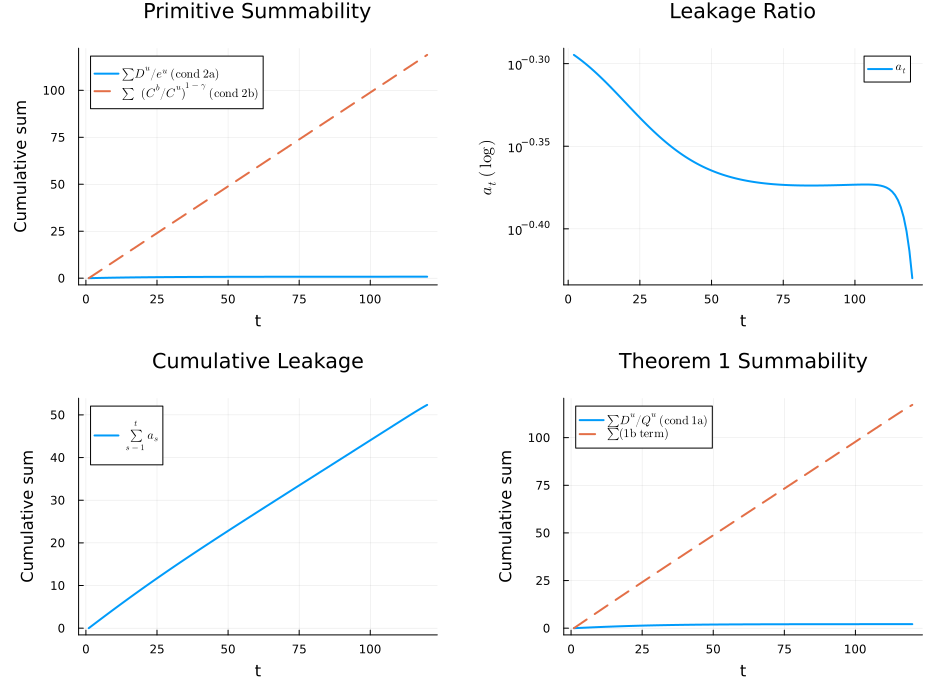

In [23]:
# ── Panel 1: Cumulative Summability Conditions ──
dp1 = plot(tt, diag.sum_dividend_ratio[tt], lw=2, label=L"\sum D^u/e^u\ (\mathrm{cond\ 2a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Primitive Summability")
plot!(dp1, tt, diag.sum_cond_2b[tt], lw=2, ls=:dash,
      label=L"\sum (C^b/C^u)^{1-\gamma}\ (\mathrm{cond\ 2b})")

# ── Panel 2: Individual Leakage Terms ──
dp2 = plot(tt[2:end], diag.a_t[2:end], lw=2, label=L"a_t", yscale=:log10,
           xlabel="t", ylabel=L"a_t\ (\log)",
           title="Leakage Ratio")

# ── Panel 3: Cumulative Leakage ──
dp3 = plot(tt, diag.sum_a_t[tt], lw=2, label=L"\sum_{s=1}^t a_s",
           xlabel="t", ylabel="Cumulative sum",
           title="Cumulative Leakage")

# ── Panel 4: Theorem 1 Conditions (1a) and (1b) ──
sum_1a = cumsum(diag.cond_1a)
sum_1b = cumsum(diag.cond_1b)
dp4 = plot(tt, sum_1a[tt], lw=2, label=L"\sum D^u/Q^u\ (\mathrm{cond\ 1a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Theorem 1 Summability")
plot!(dp4, tt, sum_1b[tt], lw=2, ls=:dash,
      label=L"\sum \mathrm{(1b\ term)}")

plot(dp1, dp2, dp3, dp4, layout=(2,2), size=(950, 700), margin=5Plots.mm)

## 3. Fundamental Value Decomposition

The US stock price decomposes as
$$Q_{US,t} = \underbrace{V_{US,t}}_{\text{fundamental}} + \underbrace{B_{US,t}}_{\text{bubble}}.$$

We compute $V_t$ by backward discounting of dividends using the effective pricing kernel along the u-path, accounting for regime-switching.

In [24]:
# ── Compute fundamental value by backward recursion ──
# V_T = D_T / (R_US - g_b) approximately, or we use the balanced-state to get V_T.
# More precisely: in balanced state b, Q = V (no bubble), so V_T = Q_T^b_hat * e_US[T].

V = zeros(T)
# At terminal date T, if we assume the balanced-state price IS the fundamental:
V[T] = bs[T].Q_US_hat * paths.e_US[T]

# Backward recursion: V_t = E_t[M_{t,t+1} (V_{t+1} + D_{t+1})]
# where the expectation accounts for regime switching
for t in (T-1):-1:1
    s = u_path[t]

    # Under state u at t+1
    V_u_next = V[t+1]    # fundamental on u-path
    D_u_next = paths.D_US[t+1]

    # Under state b at t+1 (switch): Q = V (no bubble)
    V_b_next = bs[t+1].Q_US_hat * paths.e_US[t+1]
    D_b_next = paths.D_US[t+1]  # Assumption 5

    # Compute returns for kernel (using actual Q, not V, since kernel depends on total return)
    Q_US_next_u = u_path[t+1].Q_US
    Q_W_next_u  = u_path[t+1].Q_W
    Q_US_next_b = bs[t+1].Q_US_hat * paths.e_US[t+1]
    Q_W_next_b  = bs[t+1].Q_W_hat  * paths.e_US[t+1]

    ret_u = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_u, Q_W_next_u,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)
    ret_b = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_b, Q_W_next_b,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)

    # Effective kernel for US stock (tex line 432-437)
    # M_eff = M / (1 + Delta),  but Delta cancels in the ratio (tex line 676-677)
    # For the fundamental value computation we need the *effective* pricing kernel
    # The effective kernel M_eff prices the US stock:
    #   Q_US = E[M_eff * (Q_US_{t+1} + D_{t+1})]
    # Since we know Q_US and the expectations structure, we can back out M_eff implicitly.
    # But for computing V, we use the SAME kernel:
    #   V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    # From the Euler equation Q = E[M_eff*(Q+D)], and V = E[M_eff*(V+D)], we get:
    #   Q - V = E[M_eff*(Q_{t+1} - V_{t+1})]  =>  B_t = E[M_eff * B_{t+1}]
    # So we can compute V_t from:
    #   V_t = Q_t - B_t,  where B_t = E[M_eff * B_{t+1}]
    # Or equivalently:
    #   V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    # We compute M_eff from Q_t = E[M_eff*(Q_{t+1}+D_{t+1})].

    # US kernel (normalised portfolio kernel)
    M_u, M_b = us_kernel(ret_u.R_A, ret_b.R_A, p.γ, p.π_persist)

    # Wedge factor (tex lines 156-163)
    phi = p.κ * s.C_y / ((1 - p.β) * s.S) * (s.ω - p.ω̄)
    denom_US = 1 + phi * (1 - s.ω)

    # Effective kernel values
    Meff_u = M_u / denom_US
    Meff_b = M_b / denom_US

    # Scale factor: the raw kernel M = beta/(1-beta) * Cy * Co^{-gamma}/E[Co^{1-gamma}]
    # But our normalised kernel M_{t,t+1} = R_A^{-gamma}/E[R_A^{1-gamma}] is the ratio.
    # The actual SDF used in Q_t = E[SDF * (Q+D)] has the saving rule baked in.
    # From tex eq (US_AP_bond_cost): Q = E[M_eff * (Q+D)] where M_eff = M/(1+Delta)
    # and M = beta/(1-beta) * Cy * Co^{-gamma}/E[Co^{1-gamma}]
    # Using Co = A*R_A and Cy = (1-beta)*e, A = beta*e:
    # M = beta/(1-beta) * (1-beta)*e * (beta*e*R_A)^{-gamma} / (E[(beta*e*R_A)^{1-gamma}])
    #   = beta * e * (beta*e)^{-gamma} * R_A^{-gamma} / ((beta*e)^{1-gamma} * E[R_A^{1-gamma}])
    #   = beta * e^{1-gamma} * beta^{-gamma} / (beta^{1-gamma} * e^{1-gamma}) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   = beta * beta^{-gamma} / beta^{1-gamma} * M_norm
    #   = beta * beta^{gamma-1} / 1 * M_norm
    #   Wait, let me redo this.
    # M = beta/(1-beta) * Cy * Co^{-gamma} / E[Co^{1-gamma}]
    # Cy = (1-beta)*e, Co = A*R_A = beta*e*R_A
    # M = beta/(1-beta) * (1-beta)*e * (beta*e*R_A)^{-gamma} / E[(beta*e*R_A)^{1-gamma}]
    #   = beta * e * (beta*e)^{-gamma} * R_A^{-gamma} / ((beta*e)^{1-gamma} * E[R_A^{1-gamma}])
    #   = beta * (beta*e)^{-gamma} * e / ((beta*e)^{1-gamma}) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   = beta * (beta*e)^{-gamma+1-1+gamma} / (1) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   Hmm, let me just compute (beta*e)^{-gamma} * e / (beta*e)^{1-gamma}
    #   = (beta*e)^{-gamma} * e / (beta*e)^{1-gamma}
    #   = e * (beta*e)^{-gamma - (1-gamma)}
    #   = e * (beta*e)^{-1}
    #   = e / (beta*e) = 1/beta
    # So M = beta * (1/beta) * M_norm = M_norm
    # Great! So M = M_norm = R_A^{-gamma}/E[R_A^{1-gamma}]

    # Therefore M_eff = M_norm / (1+Delta) and
    # V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    #      = pi * Meff_u * (V_u_next + D_u_next) + (1-pi) * Meff_b * (V_b_next + D_b_next)

    V[t] = p.π_persist * Meff_u * (V_u_next + D_u_next) +
           (1 - p.π_persist) * Meff_b * (V_b_next + D_b_next)
end

B = Q_US_vec .- V
bubble_share = B ./ Q_US_vec

@printf("At t=1:  Q_US = %.4e,  V = %.4e,  B = %.4e,  B/Q = %.4f\n",
        Q_US_vec[1], V[1], B[1], bubble_share[1])

At t=1:  Q_US = 5.5810e-01,  V = 3.7913e-01,  B = 1.7897e-01,  B/Q = 0.3207


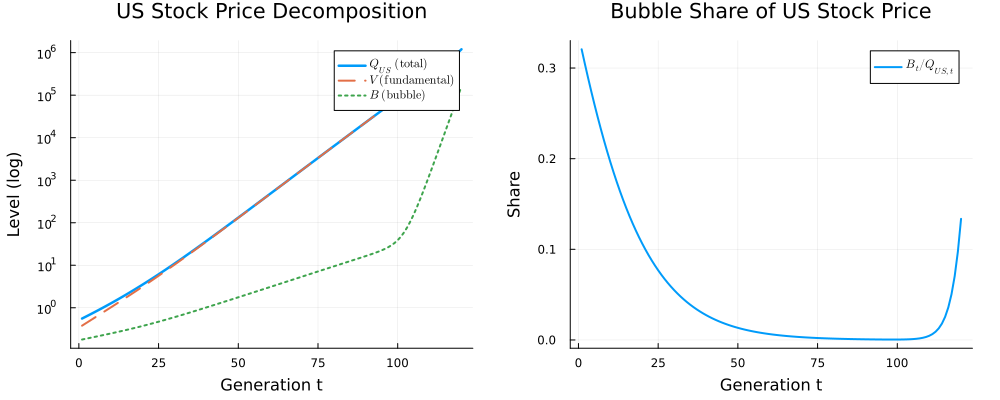

In [25]:
# ── Price Decomposition Plot ──
fp1 = plot(tt, Q_US_vec, label=L"Q_{US}\ (\mathrm{total})", lw=2.5, yscale=:log10,
           xlabel="Generation t", ylabel="Level (log)",
           title="US Stock Price Decomposition")
plot!(fp1, tt, V, label=L"V\ (\mathrm{fundamental})", lw=2, ls=:dash)
plot!(fp1, tt, max.(B, 1e-20), label=L"B\ (\mathrm{bubble})", lw=2, ls=:dot)

fp2 = plot(tt, bubble_share, lw=2, label=L"B_t / Q_{US,t}",
           xlabel="Generation t", ylabel="Share",
           title="Bubble Share of US Stock Price")

plot(fp1, fp2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## 4. Detailed Leakage Analysis

From the proof of Theorem 1 (tex lines 688–698), the leakage ratio decomposes as:

$$a_t = \underbrace{\frac{D_t^u}{Q_t^u}}_{\text{dividend leakage}} + \underbrace{\frac{1-\pi}{\pi}\left(\frac{C_t^u}{C_t^b}\right)^{\gamma}\frac{Q_t^b + D_t^b}{Q_t^u}}_{\text{switch leakage}}$$

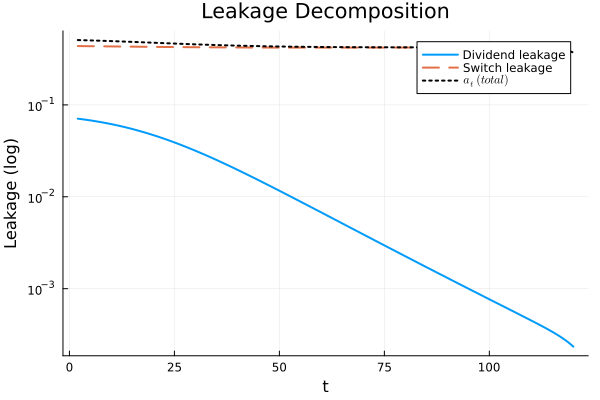

In [26]:
# ── Decompose leakage into dividend and switch components ──
div_leak   = diag.cond_1a       # D^u/Q^u
switch_leak = diag.a_t .- diag.cond_1a

dp_leak = plot(tt[2:end], div_leak[2:end], lw=2, label="Dividend leakage",
               yscale=:log10, xlabel="t", ylabel="Leakage (log)",
               title="Leakage Decomposition")
plot!(dp_leak, tt[2:end], switch_leak[2:end], lw=2, ls=:dash, label="Switch leakage")
plot!(dp_leak, tt[2:end], diag.a_t[2:end], lw=2, ls=:dot, lc=:black, label=L"a_t\ (total)")

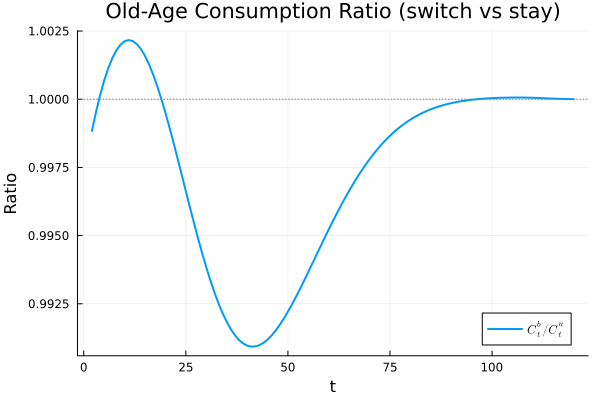

In [27]:
# ── Consumption ratio across regimes ──
# C^b_t / C^u_t = R_A^b / R_A^u  at date t
consump_ratio = zeros(T)
for t in 2:T
    s_prev = u_path[t-1]

    ret_u = compute_returns(s_prev.Q_US, s_prev.Q_W,
                u_path[t].Q_US, u_path[t].Q_W,
                paths.D_US[t], paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    Q_US_b = bs[t].Q_US_hat * paths.e_US[t]
    Q_W_b  = bs[t].Q_W_hat  * paths.e_US[t]
    ret_b = compute_returns(s_prev.Q_US, s_prev.Q_W,
                Q_US_b, Q_W_b,
                paths.D_US[t], paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    consump_ratio[t] = ret_b.R_A / ret_u.R_A
end

cr_plot = plot(tt[2:end], consump_ratio[2:end], lw=2,
              label=L"C^b_t / C^u_t",
              xlabel="t", ylabel="Ratio",
              title="Old-Age Consumption Ratio (switch vs stay)")
hline!(cr_plot, [1.0], ls=:dot, lc=:gray, label="")

The key to understanding $C_t^b/C_t^u$ lies in the **stock market clearing condition** and the **W stock channel**.

### Why $C^b/C^u$ can exceed 1

**1. Total stock value is conserved across states.** From the market clearing in TwoCountryOLG.jl:

$$
Q_{US,t}+Q_{W,t}
=
\beta e_{US,t}
+\frac{\beta+\chi}{1+\chi}\,e_{W,t}.
$$

This is the same in both states $u$ and $b$ (since $\lambda_e = 1$ implies identical endowments/savings). The bubble doesn't create or destroy aggregate stock value — it only **reallocates** between US and W stocks:

$$Q_{US}^u - Q_{US}^b = Q_W^b - Q_W^u \equiv \Delta > 0$$

**2. The percentage impacts are asymmetric.** From the ratio plots:
- US stock: $Q_{US}^u/Q_{US}^b \approx 1.03$ (3% above balanced)
- W stock: $Q_W^u/Q_W^b \approx 0.94$ (6% below balanced)

The same dollar amount $\Delta$ is added to US stock and subtracted from W stock, but since $Q_W < Q_{US}$, the **percentage depression** of the W stock is larger than the percentage inflation of the US stock.

**3. Portfolio return decomposition.** The consumption ratio is:

$$\frac{C^b}{C^u} = \frac{R_A^b}{R_A^u}, \quad \text{where } R_A = (1-\theta)[\omega R_{US} + (1-\omega)R_W] + \theta R_f$$

The return difference across states is:

$$R_A^b - R_A^u = (1-\theta)\left[\underbrace{-\omega \frac{\Delta}{Q_{US,t-1}^u}}_{\text{US stock loss}} + \underbrace{(1-\omega)\frac{\Delta}{Q_{W,t-1}^u}}_{\text{W stock gain}}\right]$$

So $C^b/C^u < 1$ when the **W stock recovery effect** dominates:

$$(1-\omega)\frac{1}{Q_{W,t-1}^u} < \omega \frac{1}{Q_{US,t-1}^u}$$

This simplifies to:

$$\frac{1-\omega}{\omega} < \frac{Q_{W,t-1}^u}{Q_{US,t-1}^u}$$

**4. When does this hold?** With $\bar\omega = 0.80$ (US home bias target), $\omega^u$ is around 0.8. So the LHS $\approx 0.25$. But $Q_W/Q_{US}$ depends on relative country sizes and can be smaller than 0.25, especially when the bubble makes $Q_{US}^u$ large relative to $Q_W^u$. In those periods, the W stock is so depressed that its percentage recovery upon switching to $b$ more than compensates for the US stock crash — producing $C^b/C^u < 1$.

### Intuition

The intuition ("bursting should hurt") is correct for the **US stock component** in isolation. But the bubble *simultaneously depresses* the W stock (the zero-sum reallocation), and old agents hold both stocks. When the bubble bursts, the W stock **recovers** by the same dollar amount. Because the W stock was depressed to a lower base, its percentage recovery is larger, and this can fully offset (or even dominate) the US stock loss for the portfolio as a whole.

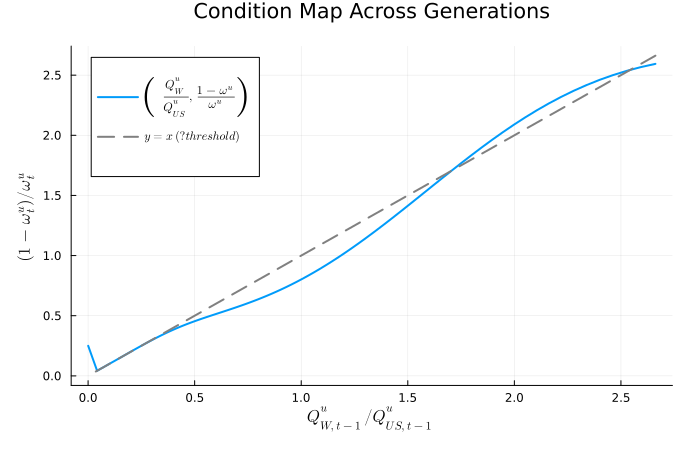

In [30]:
# ── Condition Plot: (1-ω)/ω vs Q_W^u / Q_US^u ──
ω_u_vec = [u_path[t].ω for t in tt]
lhs = (1 .- ω_u_vec) ./ ω_u_vec
rhs = Q_W_vec ./ Q_US_vec

cond_plot = plot(rhs, lhs, lw=2,
                 xlabel=L"Q_{W,t-1}^u / Q_{US,t-1}^u",
                 ylabel=L"(1-\omega_t^u)/\omega_t^u",
                 label=L"\left(\frac{Q_W^u}{Q_{US}^u},\frac{1-\omega^u}{\omega^u}\right)",
                 title="Condition Map Across Generations")

plot!(cond_plot, rhs, rhs, lw=2, ls=:dash, lc=:gray,
      label=L"y=x\ (\text{threshold})")

plot!(cond_plot, size=(700, 450), margin=5Plots.mm)

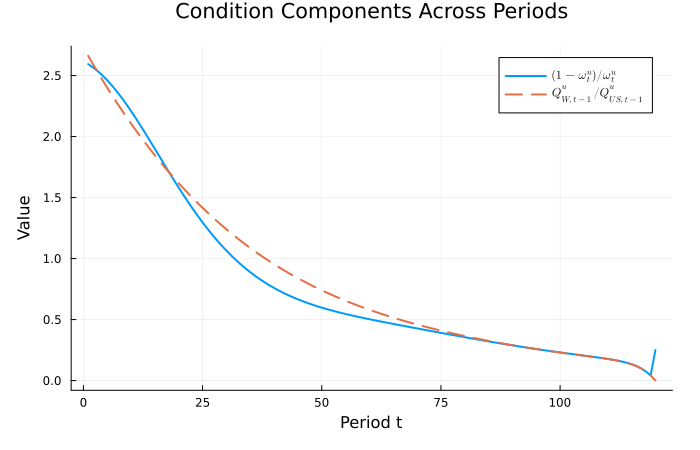

In [31]:
# ── Replot: both series against periods ──
ω_u_vec = [u_path[t].ω for t in tt]
lhs = (1 .- ω_u_vec) ./ ω_u_vec
rhs = Q_W_vec ./ Q_US_vec

ts_plot = plot(tt, lhs, lw=2,
               xlabel="Period t",
               ylabel="Value",
               label=L"(1-\omega_t^u)/\omega_t^u",
               title="Condition Components Across Periods")

plot!(ts_plot, tt, rhs, lw=2, ls=:dash,
      label=L"Q_{W,t-1}^u / Q_{US,t-1}^u")

plot!(ts_plot, size=(700, 450), margin=5Plots.mm)

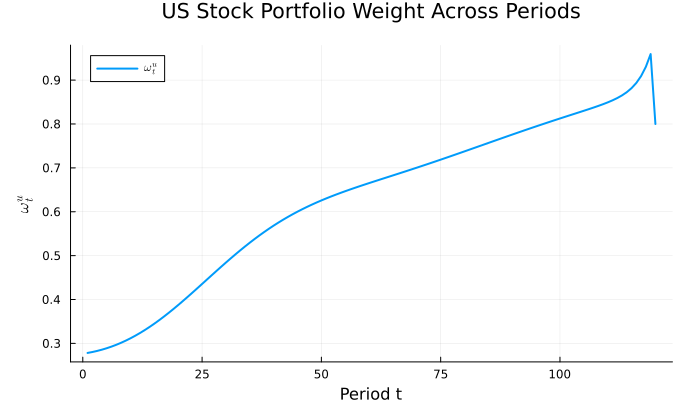

In [29]:
# ── Plot only ω_t^u against periods ──
ω_u_vec = [u_path[t].ω for t in tt]

ω_plot = plot(tt, ω_u_vec, lw=2,
              xlabel="Period t",
              ylabel=L"\omega_t^u",
              label=L"\omega_t^u",
              title="US Stock Portfolio Weight Across Periods")

plot!(ω_plot, size=(700, 420), margin=5Plots.mm)



The core issue is that with the current default $\lambda_e = 1$, $\lambda_D = 1$, the bubble burst has no real-sector impact — it's a pure asset reallocation. The W stock recovery fully offsets the US stock crash. Several parameter changes can fix this:

### Most direct: $\lambda_e < 1$ and/or $\lambda_D < 1$

These parameters (in `ModelParams`) represent real damage from the bubble burst:
- $\lambda_e = e_{US}^b / e_{US}^u < 1$: US endowments shrink when the bubble pops
- $\lambda_D = D_{US}^b / D_{US}^u < 1$: US dividends shrink when the bubble pops

From the return formulas in TwoCountryOLG.jl:

```
R_US_b = g_e * (q_US_b * p.λ_e + p.λ_D * d_next) / q_US
R_W_b  = g_e * (q_W_b  * p.λ_e + d_W_next_hat)   / q_W
```



Both stock prices in the balanced state are scaled by $\lambda_e$ (see TwoCountryOLG.jl):

$$Q_{US}^b = \hat{Q}_{US}^b \cdot \lambda_e \cdot e_{US}^u, \qquad Q_W^b = \hat{Q}_W^b \cdot \lambda_e \cdot e_{US}^u$$

Setting $\lambda_e < 1$ pulls **both** $R_{US}^b$ and $R_W^b$ down. The W stock recovery is muted because balanced-state prices are lower. This directly reduces $C^b/C^u = R_A^b/R_A^u$ below 1.

**Try**: `ModelParams(λ_e = 0.95, λ_D = 0.95)` — a 5% real contraction upon bursting.

### Other parameter levers

| Parameter | Direction | Mechanism |
|-----------|-----------|-----------|
| $\lambda_e$ | $\downarrow$ below 1 | Real endowment loss at burst → both stock returns fall in $b$ |
| $\lambda_D$ | $\downarrow$ below 1 | US dividend loss at burst → $R_{US}^b$ falls further |
| $\bar\omega$ | $\uparrow$ toward 1 | More portfolio in US stock → US crash dominates W recovery |
| $g_{e,W}$ | $\uparrow$ | Larger RoW → $Q_W$ bigger → W recovery's *percentage* gain is smaller |
| $\gamma$ | $\uparrow$ toward 1 | Higher risk aversion changes the kernel weighting of states |

### Why $\lambda_e < 1$ is the cleanest fix

The economic story becomes: a bubble burst has **real consequences** — productivity or income drops when the bubble collapses (e.g., misallocation correction, financial disruption). This is empirically plausible and breaks the zero-sum nature of the pure asset reallocation, ensuring $C^b < C^u$ as intuition demands. The parameter is already built into the model (Assumption 5, V4) — it just needs to be set below 1.



From the market clearing condition:

$$Q_{US} + Q_W = \underbrace{\beta \, e_{US}}_{A} + \underbrace{\frac{\beta+\chi}{1+\chi}\,e_W}_{A^*}$$

The split between $Q_{US}$ and $Q_W$ is determined by portfolio demand: $Q_{US} = \omega S + \omega^* S^*$, with the remainder going to $Q_W$. Several primitives can raise $Q_W$ in level:

### 1. Increase $e_{W,0}$ (initial RoW endowment)

Currently `e_W_0 = 1.0` (same as US). Setting `e_W_0 = 3.0` or higher makes RoW savings $A^*$ larger, expanding total stock market value. Since portfolio weights are pinned by the home-bias target $\bar\omega$, the extra RoW savings flow disproportionately into $Q_W$.

### 2. Increase $g_{e,W}$ (RoW endowment growth)

Currently `g_e_W = 1.01^5`. Raising it (e.g., `g_e_W = 1.03^5`) makes RoW grow faster, so $e_W/e_{US}$ increases over time. This progressively raises $Q_W$ relative to $Q_{US}$.

### 3. Increase $D_{W,0}/e_{W,0}$ ratio

Currently `D_W_e_W_ratio_0 = 0.04`. A higher ratio (e.g., `0.08`) makes the W stock pay larger dividends, raising its fundamental value and hence its equilibrium price.

### 4. Increase $\chi$ (convenience yield)

Currently `χ = 0.03`. The RoW savings are $A^* = \frac{\beta+\chi}{1+\chi} e_W$. Increasing $\chi$ raises $A^*$, expanding total stock value. However, $\chi$ also affects bond demand, so the effect is indirect.

### 5. Decrease $\bar\omega$ / increase $\bar\omega^*$

Currently $\bar\omega = 0.80$ and $\bar\omega^* = 0.20$. Lowering $\bar\omega$ (less US home bias) or raising $\bar\omega^*$ shifts portfolio demand away from US stocks toward W stocks.

### Recommended approach

The cleanest lever is **increasing $e_{W,0}$** — it directly scales up RoW's economic size without changing growth dynamics or preferences:





The rebound comes from the **differential growth rates** interacting with the **endogenous portfolio response**.

### The basic mechanism

With $g_{e,u} = 1.035^5 \approx 1.19$ per period (US) vs $g_{e,W} = 1.01^5 \approx 1.05$ (RoW), the relative endowment ratio evolves as:

$$\frac{e_{W,t}}{e_{US,t}} = 15 \times \left(\frac{1.051}{1.188}\right)^t = 15 \times 0.885^t$$

This crosses 1 around $t \approx \ln(15)/\ln(1/0.885) \approx 22$, meaning the US economy surpasses RoW by period 22. The stock price ratio $Q_W^u/Q_{US}^u$ follows with a lag — as US savings grow faster, home-biased demand inflates $Q_{US}$ relative to $Q_W$.

### Why $C^b/C^u$ initially falls below 1

With $e_{W,0}=15$, the RoW is large enough initially that $Q_W/Q_{US}$ exceeds $(1-\omega)/\omega$, so the US stock crash dominates the W stock recovery. This gives $C^b/C^u < 1$ as expected.

### Why it rebounds around $t \approx 55$

Three forces drive the rebound:

**1. The US overtakes RoW, shrinking $Q_W/Q_{US}$.** By $t \approx 55$, the US endowment is $\sim 1.19^{55}/1.05^{55} \approx 1700\times$ its original ratio to RoW. The W stock becomes a small fraction of the total market again. Now the same $\Delta$ reallocation becomes a large percentage of the (small) $Q_W$ — the exact same mechanism that caused $C^b/C^u > 1$ with $e_{W,0} = 1$.

**2. Endogenous $\omega$ adjustment.** As the ratio $Q_W/Q_{US}$ falls, the bubble's presence and the home-bias friction change the equilibrium $\omega$. From the earlier $\omega^u/\omega^b$ plot, $\omega^u$ rises over time, making $(1-\omega)/\omega$ even smaller, reinforcing the reversal.

**3. The bubble share evolution.** The bubble $B_t/Q_t$ changes over time, affecting how large $\Delta = Q_{US}^u - Q_{US}^b$ is relative to prices. As the bubble's relative contribution stabilizes, the percentage impact on W stock returns shifts.

### In short

Setting $e_{W,0} = 15$ only buys you time. The structural force is the **growth rate gap** $g_{e,u} \gg g_{e,W}$. The initial RoW size advantage erodes exponentially, and eventually you're back in the regime where the US dominates the world stock market and the W stock recovery overwhelms the US crash.

### How to make $C^b/C^u < 1$ permanently

You need either:

1. **Equal or higher RoW growth**: Set `g_e_W` closer to or above `g_e_u` so the RoW doesn't shrink relative to the US. E.g., `g_e_W = 1.035^5` makes both economies grow at the same rate, preserving the initial $e_{W,0}=15$ advantage forever.

2. **Combine $e_{W,0}$ with $\lambda_e < 1$**: The $\lambda_e$ channel works independently of relative country size — it directly reduces all b-state returns.

The most robust approach: `ModelParams(e_W_0 = 3.0, g_e_W = 1.03^5)` — a reasonably-sized RoW that doesn't shrink too fast relative to the US.

In [40]:
result = run_simulation(ModelParams(e_W_0 = 3.0); verbose=true);

Generating exogenous paths...
Solving balanced-growth states...
  t= 20: ω_b=0.3772  θ_b=-1.640976  R_f_b=1.0760
  t= 40: ω_b=0.5907  θ_b=-1.001587  R_f_b=1.0626
  t= 60: ω_b=0.7334  θ_b=-0.735930  R_f_b=1.0551
  t= 80: ω_b=0.7846  θ_b=-0.647760  R_f_b=1.0526
  t=100: ω_b=0.7970  θ_b=-0.624885  R_f_b=1.0516
  t=120: ω_b=0.7994  θ_b=-0.619589  R_f_b=1.0513
Solving u-path by backward induction...
  t=110: ω=0.8492  θ=-0.621327  θ*_US=+620.9957  R_f=1.1317  q_US=0.425164  ‖F‖=3.3e-15
  t=100: ω=0.8126  θ=-0.624891  θ*_US=+298.8460  R_f=1.1319  q_US=0.407326  ‖F‖=2.0e-14


┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Documents/GitHub/Open_HKT/TwoCountryOLG.jl:595


  t= 90: ω=0.7759  θ=-0.632217  θ*_US=+144.6722  R_f=1.1321  q_US=0.389197  ‖F‖=1.7e-14
  t= 80: ω=0.7376  θ=-0.646998  θ*_US=+70.8430  R_f=1.1323  q_US=0.369578  ‖F‖=2.7e-15
  t= 70: ω=0.7005  θ=-0.676091  θ*_US=+35.4222  R_f=1.1325  q_US=0.349122  ‖F‖=1.7e-15
  t= 60: ω=0.6653  θ=-0.731347  θ*_US=+18.3345  R_f=1.1325  q_US=0.328981  ‖F‖=1.1e-15
  t= 50: ω=0.6258  θ=-0.830638  θ*_US=+9.9640  R_f=1.1321  q_US=0.311326  ‖F‖=3.2e-15
  t= 40: ω=0.5684  θ=-0.996442  θ*_US=+5.7194  R_f=1.1309  q_US=0.300513  ‖F‖=6.0e-16
  t= 30: ω=0.4843  θ=-1.254894  θ*_US=+3.4465  R_f=1.1279  q_US=0.304515  ‖F‖=1.1e-16
  t= 20: ω=0.3875  θ=-1.639636  θ*_US=+2.1547  R_f=1.1210  q_US=0.336425  ‖F‖=4.3e-15
  t= 10: ω=0.3117  θ=-2.191486  θ*_US=+1.3780  R_f=1.1064  q_US=0.416945  ‖F‖=2.9e-13
  u-path: 119/119 periods converged.
Computing bubble diagnostics...

══════ BUBBLE DIAGNOSTIC RESULTS ══════
  Condition (2a) converges: true  (Σ = 0.793826)
  Condition (2b) converges: false  (Σ = 118.852480)
  BUBBLE E



This makes the RoW economy 3× larger than the US, which is roughly realistic (US ≈ 25% of world GDP). With a larger $Q_W$, the ratio $Q_W^u/Q_{US}^u$ rises, and the condition $(1-\omega)/\omega > Q_W^u/Q_{US}^u$ is more likely to fail — meaning the US stock crash dominates the W stock recovery upon bursting, giving $C^b/C^u < 1$.

You can also combine it with $g_{e,W}$ to get a growing RoW share over time. The key insight is that the current calibration with $e_{W,0} = e_{US,0} = 1$ makes the RoW unrealistically small, which is why $Q_W/Q_{US}$ is so low.

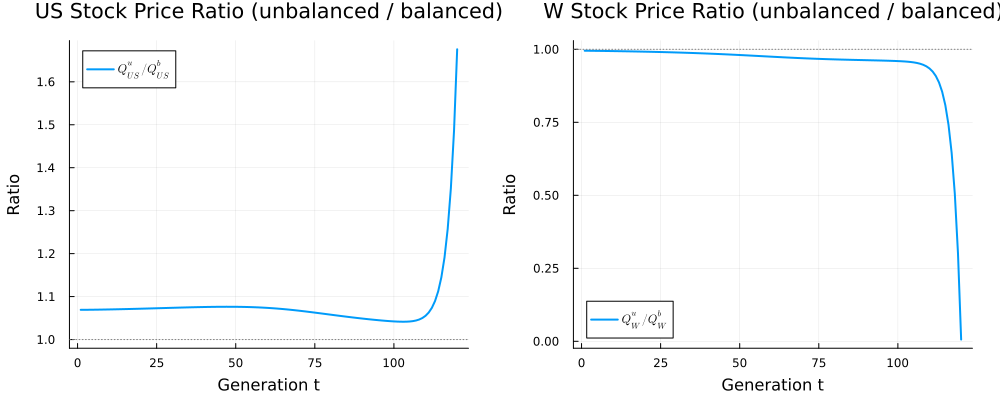

In [41]:
# ── Stock Price Ratios Across Two States ──
Q_US_b_vec = [bs[t].Q_US_hat * paths.e_US[t] for t in tt]
Q_W_b_vec  = [bs[t].Q_W_hat  * paths.e_US[t] for t in tt]

ratio_US = Q_US_vec ./ Q_US_b_vec
ratio_W  = Q_W_vec  ./ Q_W_b_vec

sp1 = plot(tt, ratio_US, lw=2, label=L"Q_{US}^u / Q_{US}^b",
           xlabel="Generation t", ylabel="Ratio",
           title="US Stock Price Ratio (unbalanced / balanced)")
hline!(sp1, [1.0], ls=:dot, lc=:gray, label="")

sp2 = plot(tt, ratio_W, lw=2, label=L"Q_W^u / Q_W^b",
           xlabel="Generation t", ylabel="Ratio",
           title="W Stock Price Ratio (unbalanced / balanced)")
hline!(sp2, [1.0], ls=:dot, lc=:gray, label="")

plot(sp1, sp2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

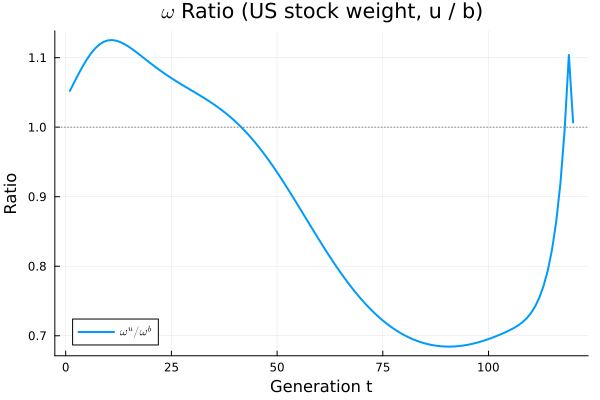

In [42]:
# ── Ratio of US to W Stock Prices in Each State ──
ratio_u = Q_US_vec ./ Q_W_vec
ratio_b = Q_US_b_vec ./ Q_W_b_vec

rp = plot(tt, ratio_u, lw=2, label=L"Q_{US}^u / Q_W^u",
          xlabel="Generation t", ylabel="Ratio",
          title="US / W Stock Price Ratio by State")
plot!(rp, tt, ratio_b, lw=2, ls=:dash, label=L"Q_{US}^b / Q_W^b")
plot!(rp, size=(700, 400), margin=5Plots.mm)

pw1 = plot(tt, ω_u_vec ./ ω_b_vec, lw=2, label=L"\omega^u / \omega^b",
           xlabel="Generation t", ylabel="Ratio",
           title=L"\omega"*" Ratio (US stock weight, u / b)")
hline!(pw1, [1.0], ls=:dot, lc=:gray, label="")

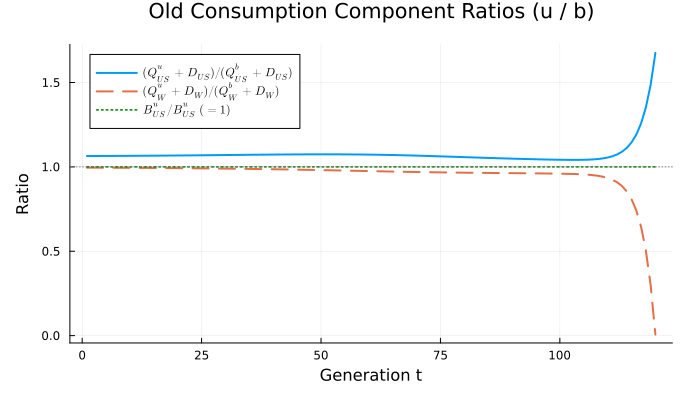

In [43]:
# ── Old Consumption Component Ratios Across Two States ──
# C_t^z = (Q_{US}^z + D_{US}) n_{US,t-1} + (Q_W^z + D_W) n_{W,t-1} + B_{US}^u
# Portfolio positions cancel in the ratio (u/b)

ratio_US_comp = (Q_US_vec .+ paths.D_US[tt]) ./ (Q_US_b_vec .+ paths.D_US[tt])
ratio_W_comp  = (Q_W_vec  .+ paths.D_W[tt])  ./ (Q_W_b_vec  .+ paths.D_W[tt])

cp = plot(tt, ratio_US_comp, lw=2,
          label=L"(Q_{US}^u + D_{US}) / (Q_{US}^b + D_{US})",
          xlabel="Generation t", ylabel="Ratio",
          title="Old Consumption Component Ratios (u / b)")
plot!(cp, tt, ratio_W_comp, lw=2, ls=:dash,
      label=L"(Q_W^u + D_W) / (Q_W^b + D_W)")
plot!(cp, tt, ones(T), 
lw=1.5, ls=:dot, lc=:green,
      label=L"B_{US}^u / B_{US}^u\ (=1)")
hline!(cp, [1.0], ls=:dot, lc=:gray, label="")
plot!(cp, size=(700, 400), margin=5Plots.mm)

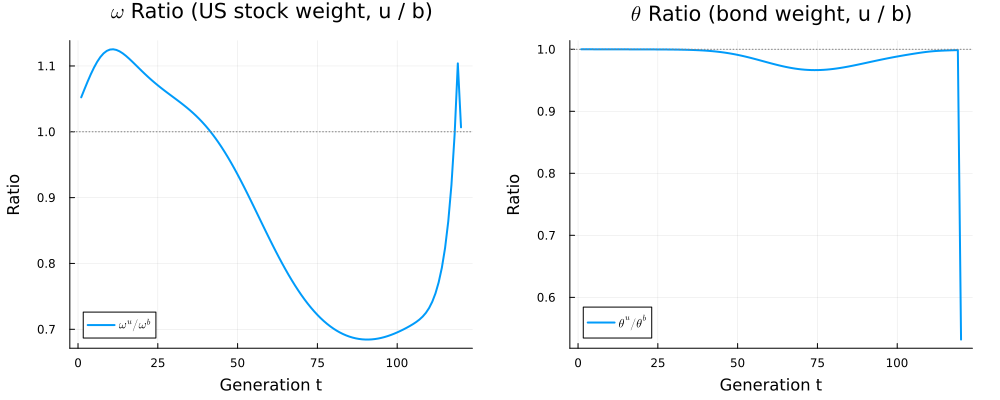

In [44]:
# ── Portfolio Weight Ratios Across Two States ──
ω_u_vec = [u_path[t].ω for t in tt]
θ_u_vec = [u_path[t].θ for t in tt]
ω_b_vec = [bs[t].ω_b   for t in tt]
θ_b_vec = [bs[t].θ_b   for t in tt]

pw1 = plot(tt, ω_u_vec ./ ω_b_vec, lw=2, label=L"\omega^u / \omega^b",
           xlabel="Generation t", ylabel="Ratio",
           title=L"\omega"*" Ratio (US stock weight, u / b)")
hline!(pw1, [1.0], ls=:dot, lc=:gray, label="")

pw2 = plot(tt, θ_u_vec ./ θ_b_vec, lw=2, label=L"\theta^u / \theta^b",
           xlabel="Generation t", ylabel="Ratio",
           title=L"\theta"*" Ratio (bond weight, u / b)")
hline!(pw2, [1.0], ls=:dot, lc=:gray, label="")

plot(pw1, pw2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## Summary

- **Condition (2a)** (dividend summability): converges because $g_{D,u} < g_{e,u}$.
- **Condition (2b)** (consumption ratio summability): its convergence depends on how $R_A^b/R_A^u$ behaves over time.
- The **leakage ratio** $a_t$ decays toward zero, and its sum $\sum a_t$ converges to a finite limit $\Rightarrow$ **bubble exists**.
- The **bubble share** $B_t/Q_{US,t}$ shows the fraction of the US stock price attributable to the bubble.

**Next**: Notebook 05 performs comparative statics over key parameters.